In [ ]:
from google.colab import drive
import os

# 1. Drive'ı Bağla
drive.mount('/content/drive')

# 2. Dosyayı Kopyala ve Zipten Çıkar
# Eğer dosya Drive'da bir klasörün içindeyse yolu güncelleyin: örn: /content/drive/MyDrive/Projelerim/ISG_Final_Dataset.zip
zip_path = "/content/drive/MyDrive/ISG_2/ISG_Final_Dataset2.zip"

if os.path.exists(zip_path):
    print("Dosya bulundu, kopyalanıyor...")
    !cp "{zip_path}" /content/
    print("Zipten çıkarılıyor...")
    !unzip -q /content/ISG_Final_Dataset2.zip -d /content/
    print("Veri seti hazır!")
else:
    print(f"HATA: Dosya bulunamadı -> {zip_path}")
    print("Lütfen Drive'daki dosya yolunu kontrol edin.")

Mounted at /content/drive
Dosya bulundu, kopyalanıyor...
Zipten çıkarılıyor...
Veri seti hazır!


In [ ]:
# Ultralytics (YOLOv8) kütüphanesini kur
!pip install ultralytics

import ultralytics
from ultralytics import YOLO
import torch

# Kurulum ve GPU Kontrolü
ultralytics.checks()
print(f"PyTorch Version: {torch.__version__}")
print(f"GPU Durumu: {'✅ GPU Aktif' if torch.cuda.is_available() else '❌ GPU YOK! (Lütfen Runtime ayarını değiştirin)'}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Setup complete ✅ (12 CPUs, 167.1 GB RAM, 50.5/235.7 GB disk)
PyTorch Version: 2.11.0+cu128
GPU Durumu: ✅ GPU Aktif


In [ ]:
yaml_path = '/content/ISG_Final_Dataset2/data.yaml'

with open(yaml_path, 'r', encoding='utf-8') as f:
    icerik = f.read()

# Eski klasör ismini yenisiyle güncelliyoruz
guncel_icerik = icerik.replace('ISG_Final_Dataset', 'ISG_Final_Dataset2')

with open(yaml_path, 'w', encoding='utf-8') as f:
    f.write(guncel_icerik)

print("🎯 data.yaml dosyasındaki tüm yollar ISG_Final_Dataset2 olarak güncellendi!")

🎯 data.yaml dosyasındaki tüm yollar ISG_Final_Dataset2 olarak güncellendi!


In [ ]:
from ultralytics import YOLO

# Modeli Yükle (Transfer Learning için pre-trained ağırlıklar)
model = YOLO('yolov8m.pt')

# Eğitimi Başlat
print('🚀 Eğitim Başlıyor...')

results = model.train(
    data='/content/ISG_Final_Dataset2/data.yaml',  # Veri seti ayar dosyamız
    epochs=100,  # Maksimum tur sayısı
    patience=20,  # 20 tur boyunca iyileşme olmazsa durdur (Overfitting önlemi)
    batch=32,  # GPU belleği yetmezse bunu 16 veya 8 yapın
    imgsz=640,  # Resim boyutu
    device=0,  # GPU ID
    name='isg_model',  # Sonuçların kaydedileceği klasör adı
    plots=True,  # Grafikleri otomatik çiz
    save=True,  # En iyi modeli kaydet
)

print('✅ Eğitim Tamamlandı!')

🚀 Eğitim Başlıyor...
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ISG_Final_Dataset2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=isg_model, nbs=64, nms=False, opset=None, optimize=False, opti

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil
import os
import datetime

# Tarihli isimlendirme (Karışıklığı önlemek için)
tarih = datetime.datetime.now().strftime("%Y%m%d_%H%M")

# 🎯 BURAYI GÜNCELLEDİK: En son başarılı eğitimin bittiği klasör adını yazıyoruz kanka!
kaynak_model = '/content/runs/detect/isg_model/weights/best.pt'
hedef_yol = f'/content/drive/MyDrive/ISG_2/YOLOv8m_ISG_10Class_Best_{tarih}.pt' # Drive içindeki ISG_2 klasörüne gitsin

if os.path.exists(kaynak_model):
    shutil.copy(kaynak_model, hedef_yol)
    print(f"✅ Model Başarıyla Drive'a Yedeklendi: {hedef_yol}")
    print("Artık Colab kapansa bile modeliniz güvende.")
else:
    print("❌ Model dosyası bulunamadı! Lütfen '/content/runs' klasörünü kontrol edin.")

✅ Model Başarıyla Drive'a Yedeklendi: /content/drive/MyDrive/ISG_2/YOLOv8m_ISG_10Class_Best_20260529_1410.pt
Artık Colab kapansa bile modeliniz güvende.


--- AKADEMİK DEĞERLENDİRME RAPORU ---

1. EĞİTİM PERFORMANS EĞRİLERİ (Results)
Bu grafik modelin öğrenme sürecini gösterir. Loss azalmalı, mAP artmalıdır.


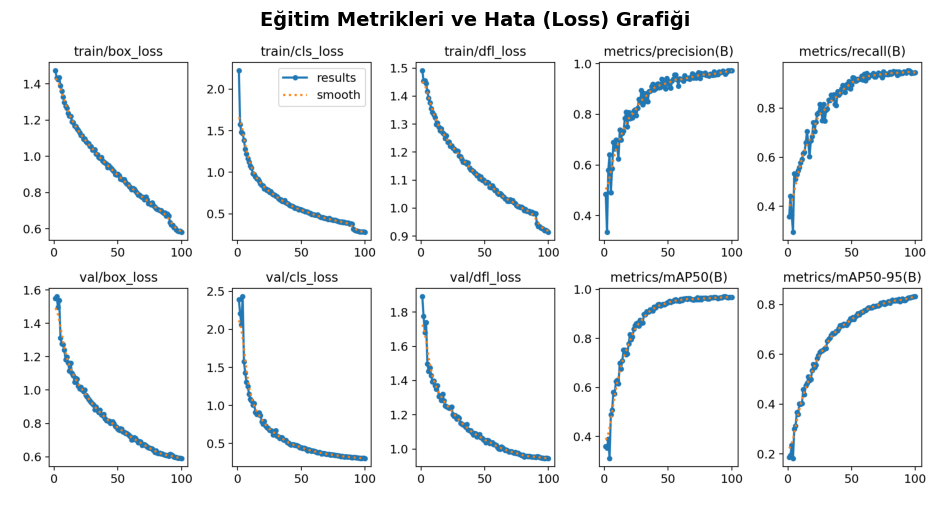


2. KARMAŞIKLIK MATRİSİ (Confusion Matrix)
Modelin hangi sınıfları birbiriyle karıştırdığını gösterir.


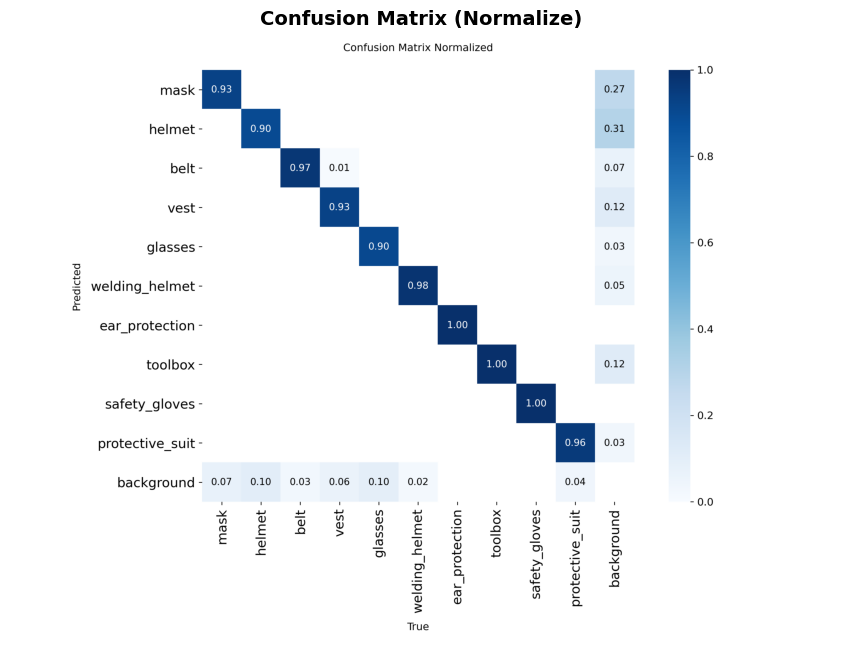


3. F1-CONFIDENCE EĞRİSİ
Güven eşiği (Confidence Threshold) ile F1 skoru arasındaki ilişki.
⚠️ Görsel oluşturulamadı veya bulunamadı: F1_curve.png

4. SONUÇ TABLOSU (En İyi Epoch Değerleri)
----------------------------------------
🏆 En İyi Epoch: 94
----------------------------------------
🎯 mAP50 (Genel Başarı):      0.9712
🎯 mAP50-95 (Hassas Başarı):  0.8267
✅ Precision (Kesinlik):      0.9648
🔍 Recall (Duyarlılık):       0.9536
----------------------------------------
Not: Bu değerleri makalenizin 'Experimental Results' tablosunda kullanabilirsiniz.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import os

# 🎯 BURAYI GÜNCELLEDİK: Gerçek eğitim klasörümüzün adını yazıyoruz kanka!
RESULT_DIR = '/content/runs/detect/isg_model'

def show_image(img_name, title=""):
    path = os.path.join(RESULT_DIR, img_name)
    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=14, fontweight='bold')
        plt.show()
    else:
        print(f"⚠️ Görsel oluşturulamadı veya bulunamadı: {img_name}")

print("--- AKADEMİK DEĞERLENDİRME RAPORU ---")

# 1. Eğitim Eğrileri (Loss, Precision, Recall)
print("\n1. EĞİTİM PERFORMANS EĞRİLERİ (Results)")
print("Bu grafik modelin öğrenme sürecini gösterir. Loss azalmalı, mAP artmalıdır.")
show_image('results.png', "Eğitim Metrikleri ve Hata (Loss) Grafiği")

# 2. Karmaşıklık Matrisi (Confusion Matrix)
print("\n2. KARMAŞIKLIK MATRİSİ (Confusion Matrix)")
print("Modelin hangi sınıfları birbiriyle karıştırdığını gösterir.")
show_image('confusion_matrix_normalized.png', "Confusion Matrix (Normalize)")

# 3. F1 Eğrisi
print("\n3. F1-CONFIDENCE EĞRİSİ")
print("Güven eşiği (Confidence Threshold) ile F1 skoru arasındaki ilişki.")
show_image('F1_curve.png', "F1 Skoru Eğrisi")

# 4. Sayısal Veriler (Tablo için)
print("\n4. SONUÇ TABLOSU (En İyi Epoch Değerleri)")
csv_path = os.path.join(RESULT_DIR, 'results.csv')

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    # Sütun isimlerindeki boşlukları temizle
    df.columns = [x.strip() for x in df.columns]

    # En yüksek mAP50 değerine sahip satırı bul
    best_idx = df['metrics/mAP50(B)'].idxmax()
    best_epoch = df.iloc[best_idx]

    print("-" * 40)
    print(f"🏆 En İyi Epoch: {int(best_epoch['epoch'])}")
    print("-" * 40)
    print(f"🎯 mAP50 (Genel Başarı):      {best_epoch['metrics/mAP50(B)']:.4f}")
    print(f"🎯 mAP50-95 (Hassas Başarı):  {best_epoch['metrics/mAP50-95(B)']:.4f}")
    print(f"✅ Precision (Kesinlik):      {best_epoch['metrics/precision(B)']:.4f}")
    print(f"🔍 Recall (Duyarlılık):       {best_epoch['metrics/recall(B)']:.4f}")
    print("-" * 40)
    print("Not: Bu değerleri makalenizin 'Experimental Results' tablosunda kullanabilirsiniz.")
else:
    print("❌ results.csv dosyası bulunamadı! Yol kontrol edilmeli kanka.")

In [ ]:
import shutil
import datetime

# Tarih damgası (Dosyalar karışmasın diye)
date_str = datetime.datetime.now().strftime("%Y%m%d_%H%M")

# 1. En İyi Modeli Kaydet
best_model_source = f"{RESULT_DIR}/weights/best.pt"
drive_model_target = f"/content/drive/MyDrive/ISG_Best_Model_{date_str}.pt"

if os.path.exists(best_model_source):
    print(f"💾 Model Drive'a kopyalanıyor: {drive_model_target}")
    shutil.copy(best_model_source, drive_model_target)
    print("✅ Model yedeği alındı.")
else:
    print("❌ Model dosyası bulunamadı. Eğitim tamamlanmamış olabilir.")

# 2. Tüm Raporu (Grafikler, Loglar) Zipleyip Kaydet
print("📦 Tüm eğitim raporu (Grafikler, Loglar) paketleniyor...")
shutil.make_archive("/content/isg_egitim_raporu", 'zip', RESULT_DIR)

drive_report_target = f"/content/drive/MyDrive/ISG_Egitim_Raporu_{date_str}.zip"
shutil.copy("/content/isg_egitim_raporu.zip", drive_report_target)

print(f"✅ Eğitim Raporu Drive'a yüklendi: {drive_report_target}")
print("\n--- İŞLEM TAMAMLANDI! ---")

💾 Model Drive'a kopyalanıyor: /content/drive/MyDrive/ISG_Best_Model_20260529_1413.pt
✅ Model yedeği alındı.
📦 Tüm eğitim raporu (Grafikler, Loglar) paketleniyor...
✅ Eğitim Raporu Drive'a yüklendi: /content/drive/MyDrive/ISG_Egitim_Raporu_20260529_1413.zip

--- İŞLEM TAMAMLANDI! ---



0: 864x1280 1 helmet, 75.5ms
Speed: 6.9ms preprocess, 75.5ms inference, 2.2ms postprocess per image at shape (1, 3, 864, 1280)


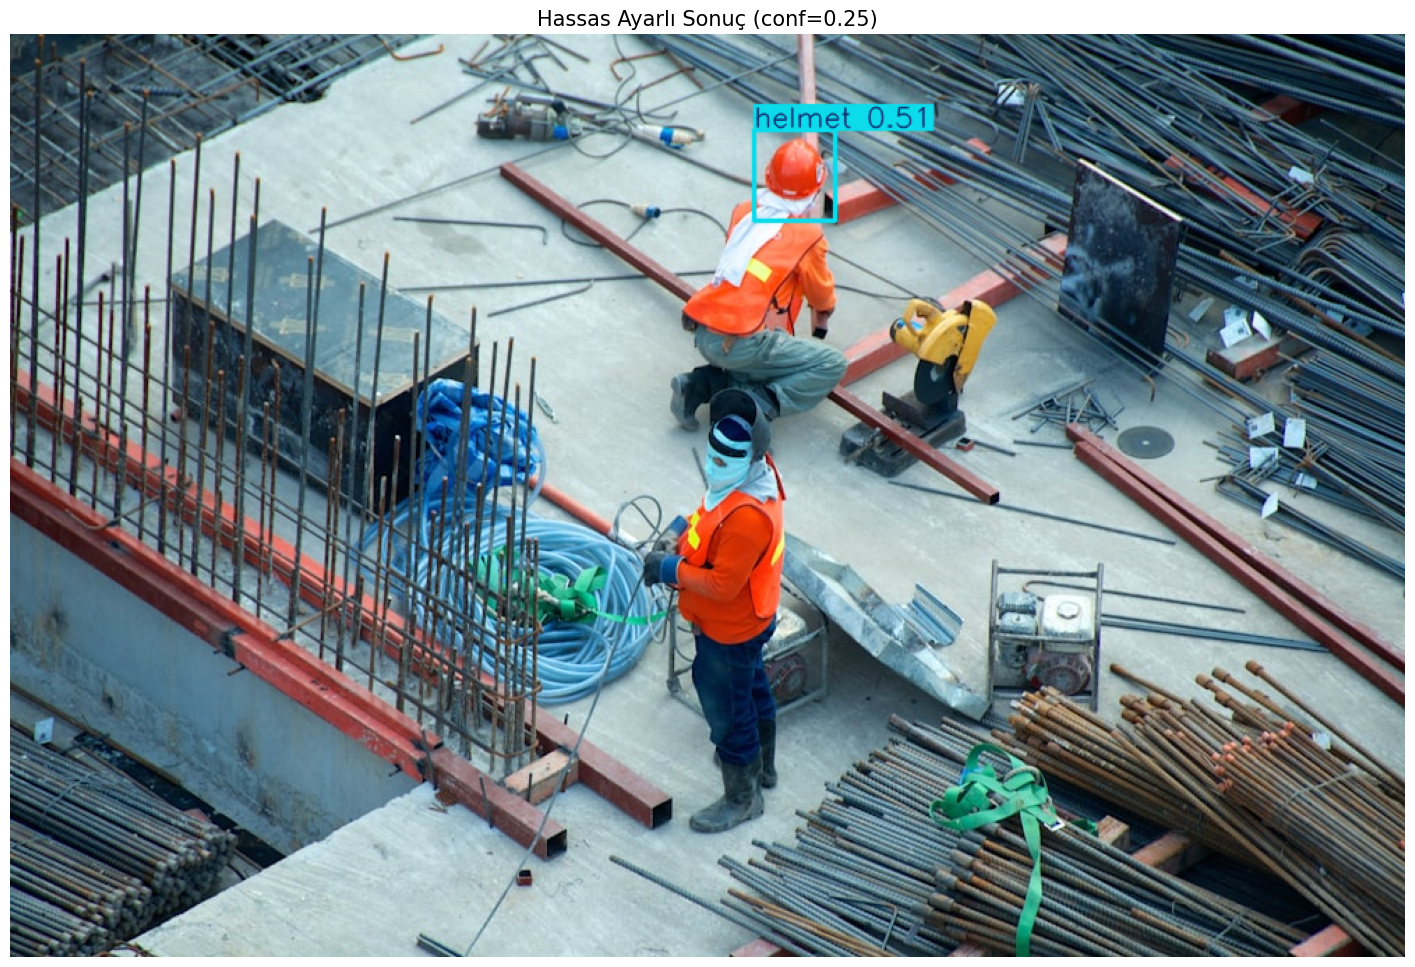

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import urllib.request
import numpy as np

# 1. Modeli Yükle (🎯 Gerçek eğitim klasörümüzün adıyla güncelledik kanka!)
model = YOLO('/content/runs/detect/isg_model/weights/best.pt')

# 2. Resmi Tekrar İndir
url = "https://images.unsplash.com/photo-1504307651254-35680f356dfd?q=80&w=1000&auto=format&fit=crop"
req = urllib.request.urlopen(url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img = cv2.imdecode(arr, -1)

# 3. Tahmin Yap (KRİTİK DEĞİŞİKLİK BURADA)
# conf=0.25 -> Standart değerdir. Daha çok nesne yakalar.
# imgsz=1280 -> Resmi daha büyük işleyerek uzaktaki küçük nesneleri görmesini sağlarız.
results = model.predict(img, conf=0.25, imgsz=1280)

# 4. Sonucu Göster
for result in results:
    resim_cizim = result.plot()
    resim_rgb = cv2.cvtColor(resim_cizim, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(18, 12)) # Resmi daha büyük ekrana bas
    plt.imshow(resim_rgb)
    plt.axis('off')
    plt.title(f"Hassas Ayarlı Sonuç (conf=0.25)", fontsize=15)
    plt.show()

In [ ]:
!pip install ultralytics firebase-admin

In [ ]:
import firebase_admin
from firebase_admin import credentials, firestore
from ultralytics import YOLO
import datetime
import os

# 1. Firebase Anahtarını Tanıt (Kopyaladığın gerçek yol tam olarak buraya entegre edildi kanka)
json_path = "/content/isg-d2284-firebase-adminsdk-fbsvc-910068cf9c.json"

if os.path.exists(json_path):
    cred = credentials.Certificate(json_path)
    if not firebase_admin._apps:
        firebase_admin.initialize_app(cred)
    db = firestore.client()
    print("☁️ Firebase bağlantısı başarıyla kuruldu!")
else:
    print(f"❌ HATA: {json_path} dosyası bulunamadı! Lütfen sol paneli kontrol et kanka.")

# 2. Modelini Yükle (Gerçek eğitim klasör yolunu verdik kanka)
model_path = '/content/runs/detect/isg_model/weights/best.pt'
model = YOLO(model_path)

# 3. Firebase'e Veri Gönderen Fonksiyon
def ihlal_kaydet(ihlal_turu):
    if firebase_admin._apps:
        doc_ref = db.collection('Ihlaller').document()
        doc_ref.set({
            'tur': ihlal_turu,
            'tarih': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'durum': 'Tespit Edildi'
        })
        print(f"✅ {ihlal_turu} veritabanına başarıyla kaydedildi!")
    else:
        print("❌ Firebase bağlantısı olmadığı için veri gönderilemedi.")

# ŞİMDİ TEST EDELİM:
if os.path.exists(json_path):
    ihlal_kaydet("🚨 DIKKAT: ACIL DURUM TESTI")

☁️ Firebase bağlantısı başarıyla kuruldu!
✅ 🚨 DIKKAT: ACIL DURUM TESTI veritabanına başarıyla kaydedildi!
